### Step 1: Preparing the Notebook & Loading Data

In [1]:
# import statements

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import silhouette_samples

In [2]:
# read the dataset
df = pd.read_csv("data/credit_card.csv")

In [3]:
# view the data and its structure
print(f"Shape: {df.shape}")
print("Column dtypes:")
print(df.dtypes)

Shape: (661, 7)
Column dtypes:
Sl_No                    int64
Customer Key             int64
Avg_Credit_Limit       float64
Total_Credit_Cards     float64
Total_visits_bank      float64
Total_visits_online    float64
Total_calls_made       float64
dtype: object


### Step 2: Data Preview & Cleanup

#### Data Preview

To start the data preview step, I created histograms to preview what the data looks like visually.

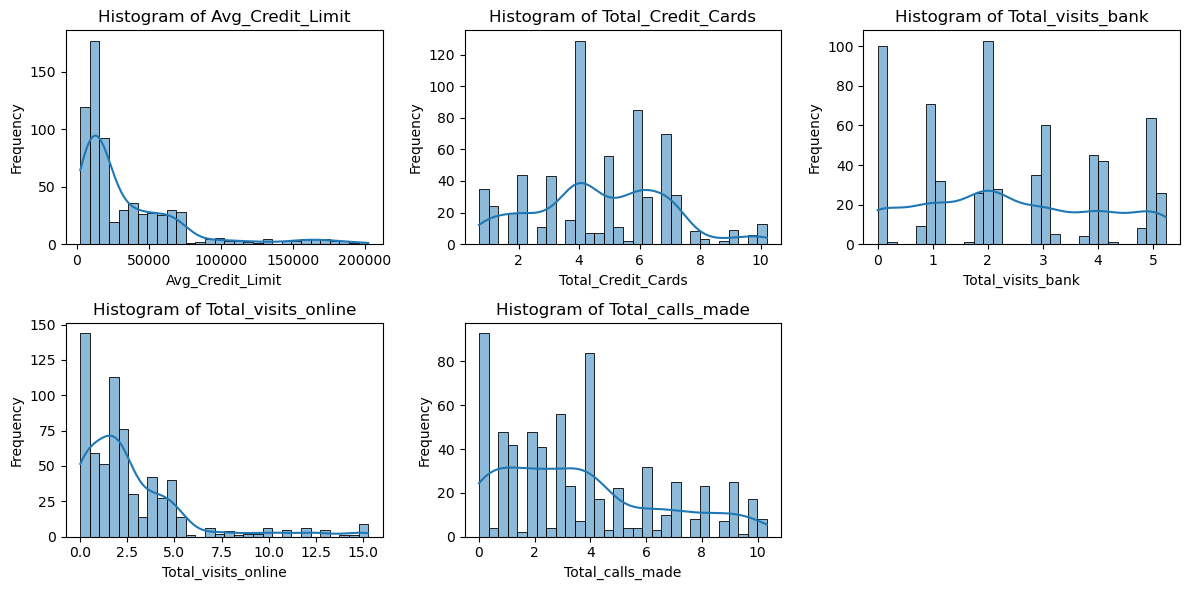

In [4]:
# Histograms for each feature
features = [col for col in df.columns if col not in ["Sl_No", "Customer Key"]]

plt.figure(figsize=(12, 6))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<br>


#### Data Cleanup

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64


In [6]:
df.head(10)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,6,58634,20897.397884,3.005451,0.000000,0.984746,8.163205
1,1,87073,102487.143050,2.025961,0.974730,1.450667,0.200438
2,2,38414,49898.381255,3.051377,0.091629,9.831703,9.090216
3,3,17341,50303.242886,6.963332,0.977077,2.946968,4.185461
4,4,40496,30024.937358,4.794870,1.158414,1.011002,4.118329
5,5,47437,98738.336448,5.894122,0.048569,12.202551,2.653637
6,6,58634,20897.397884,3.005451,0.000000,0.984746,8.163205
7,7,48370,100723.217163,5.014062,0.000000,11.027256,2.144424
8,8,37376,17844.334829,2.803481,0.000000,1.091048,0.860484
9,9,82490,3739.426372,2.064491,0.000000,2.183157,1.837701


In [7]:
# function to remove unnecessary columns
def drop_columns(df, cols):
    df = df.drop(columns=cols)
    return df


df = drop_columns(df, ["Sl_No", "Customer Key"])
df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,20897.397884,3.005451,0.000000,0.984746,8.163205
1,102487.143050,2.025961,0.974730,1.450667,0.200438
2,49898.381255,3.051377,0.091629,9.831703,9.090216
3,50303.242886,6.963332,0.977077,2.946968,4.185461
4,30024.937358,4.794870,1.158414,1.011002,4.118329


In [8]:
# before outlier removal:
df.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,661.000000,661.000000,661.000000,661.000000,661.000000
mean,34586.995118,4.708933,2.405136,2.621419,3.604839
std,37676.697679,2.170873,1.628319,2.925118,2.855329
min,2447.258852,0.693487,0.000000,0.000000,0.000000
25%,10457.642676,3.079465,1.009576,0.856493,1.092525
50%,17844.334829,4.786931,2.067974,1.949965,3.070870
75%,48121.119645,6.134803,3.953999,3.833521,5.211724
max,202492.723942,10.210266,5.224664,15.289569,10.336919


In [20]:
# after outlier removal
df_clean = df.copy()

for col in df_clean.select_dtypes(include=[np.number]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    before = len(df_clean)
    df_clean = df_clean[df_clean[col].between(
        lower, upper)].reset_index(drop=True)
    after = len(df_clean)

    print(f"{col}: removed {before - after} records that were outliers.")

print(f"Total rows after cleaning: {len(df_clean)}")

df_clean.describe()

Avg_Credit_Limit: removed 39 records that were outliers.
Total_Credit_Cards: removed 0 records that were outliers.
Total_visits_bank: removed 0 records that were outliers.
Total_visits_online: removed 10 records that were outliers.
Total_calls_made: removed 0 records that were outliers.
Total rows after cleaning: 612


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,612.000000,612.000000,612.000000,612.000000,612.000000
mean,26058.388553,4.395513,2.548609,1.948240,3.793480
std,21153.734236,1.892257,1.602306,1.584050,2.857717
min,2447.258852,0.693487,0.000000,0.000000,0.000000
25%,10104.755326,3.012324,1.094341,0.783538,1.194965
50%,16531.032584,4.121969,2.121008,1.902938,3.214382
75%,39014.928482,6.015155,3.979017,2.942999,5.895696
max,102487.143050,9.190261,5.224664,7.889267,10.336919


#### Data Cleanup Analysis

For data cleanup, there was no NULL records to remove. The reason for looking at the first 10 rows with head(10) was to determine if the records that hasv 0.00 were valid entries. These were either in Total_visits_bank, Total_visits_online, or Total_calls_made, but having 0 for these values is jsutified because the other online communication platforms were higher. Because of this, I did not drop any of the records that contained 0.00 as a value.

As another step for cleanup, I dropped the outliers using 1.5 * IQR to drop records outside the IQR range. It is worth nothing that this mostly removed high credit limit customers.



###  Visualization of data cleanup

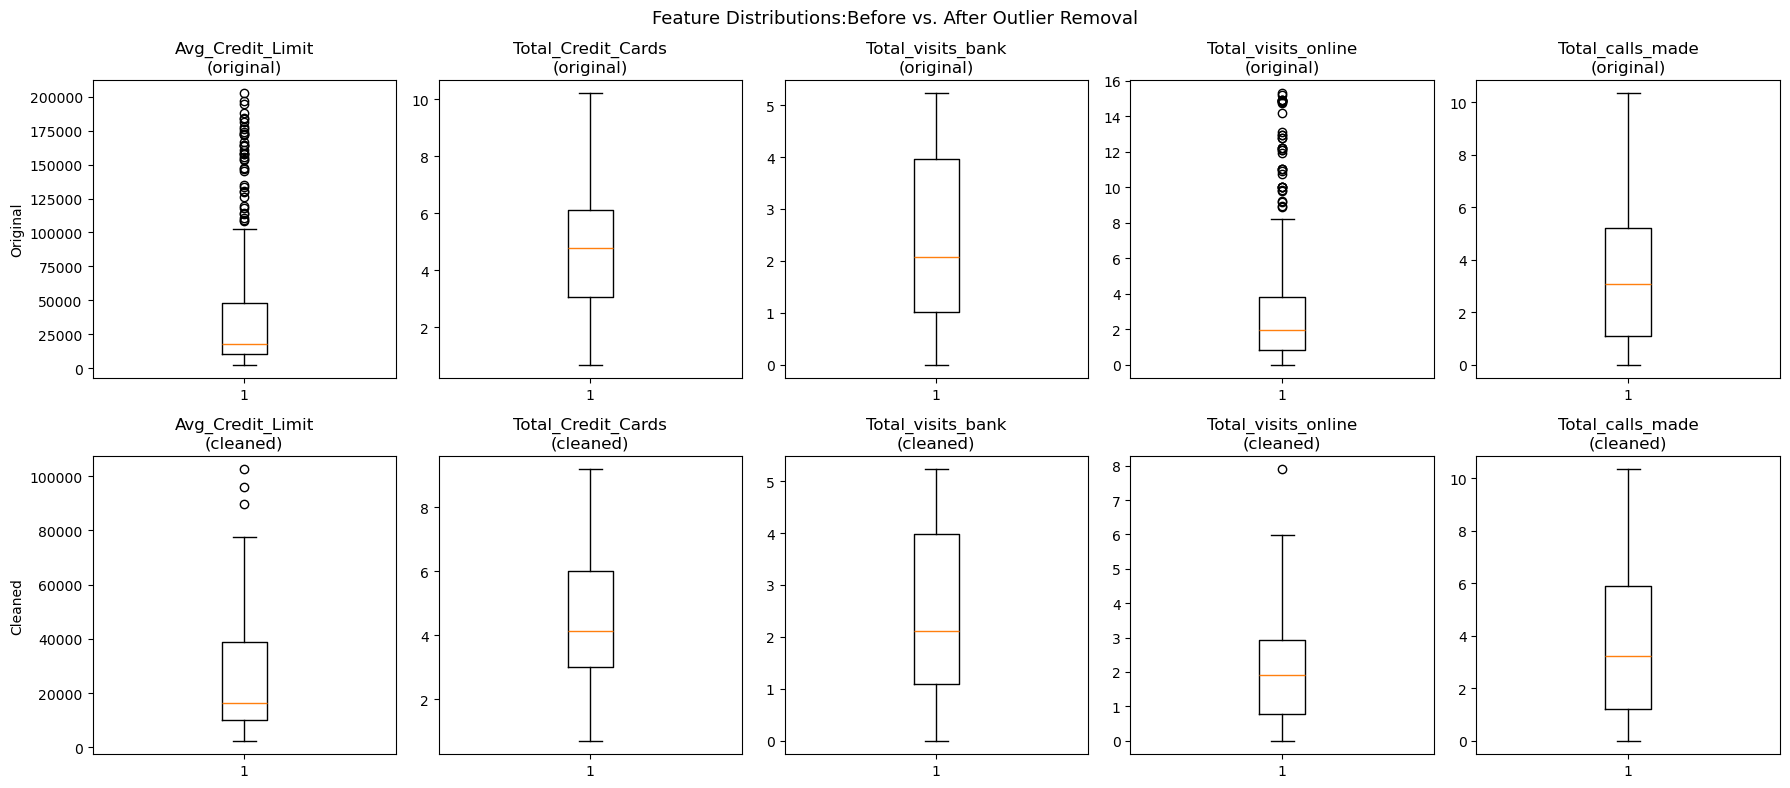

In [ ]:
def plot_distributions(df_original, df_clean):
    # Plot side-by-side boxplots for original vs. cleaned data
    features = df_original.columns.tolist()
    fig, axes = plt.subplots(2, len(features), figsize=(18, 8))

    for i, col in enumerate(features):
        axes[0, i].boxplot(df_original[col].dropna())
        axes[0, i].set_title(f"{col}\n(original)")
        axes[1, i].boxplot(df_clean[col].dropna())
        axes[1, i].set_title(f"{col}\n(cleaned)")

    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Cleaned")
    plt.suptitle(
        "Feature Distributions: Before vs. After Outlier Removal", fontsize=13
    )
    plt.tight_layout()
    plt.show()


plot_distributions(df, df_clean)

### Step 3: Feature Scaling

Standardize all numerical features using StandardScaler.



In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X = pd.DataFrame(X_scaled, columns=df_clean.columns)

print(f"Scaled shape: {X.shape}")
X.head()

Scaled shape: (612, 5)


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,-0.244175,-0.735206,-1.591890,-0.608745,1.530348
1,3.615970,-1.253260,-0.983063,-0.314372,-1.258341
2,1.147064,1.358124,-0.981597,0.631006,0.137278
3,0.187664,0.211221,-0.868332,-0.592156,0.113767
4,-0.244175,-0.735206,-1.591890,-0.608745,1.530348


### Step 4: K Means Clsutering
Determining the optimal number of clusters

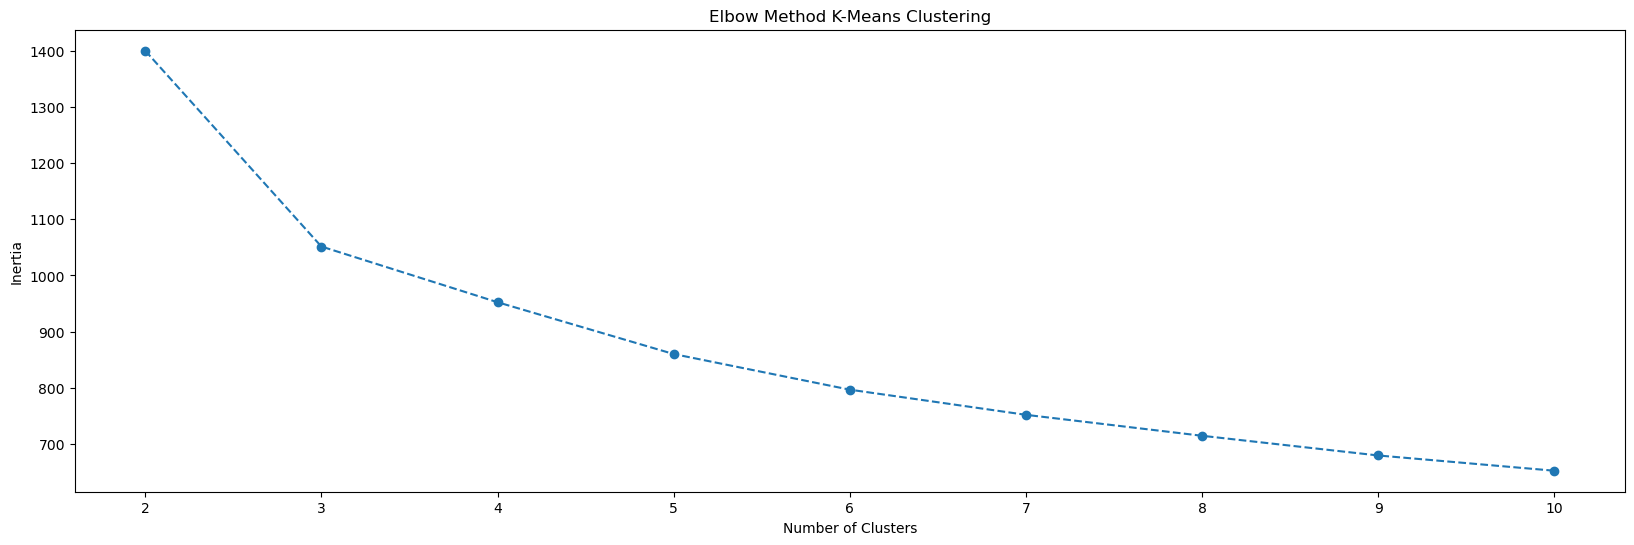

In [12]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 6))
plt.plot(list(k_values), inertia, marker="o", linestyle="--")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method K-Means Clustering")
plt.show()

#### Analysis on Optimal K

To identify the optimal K value, we must plot inertia over K, and selet the point where the curve levels off. Based on the chart, I believe the curve starts leveling off where k = 3, and that is the optimal number of clusters.


### Step 5: Training a K Means Model.

In [13]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean["KMeans_Cluster"] = kmeans.fit_predict(X)

print("Cluster counts:")
print(df_clean["KMeans_Cluster"].value_counts().sort_index())

# Inverse transform centroids back to original feature space
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

Cluster counts:
KMeans_Cluster
0    230
1    160
2    222
Name: count, dtype: int64


### Step 6: Agglomerative Clustering

In [14]:
# Apply Agglomerative Clustering with same k as K-Means
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
df_clean["Agg_Cluster"] = agg.fit_predict(X)

### Step 7: Comparison of Agglomerative Clustering vs K-means
To do a comparison, I have created a scatterplot of steps 5 and 6 to visually compare them. 

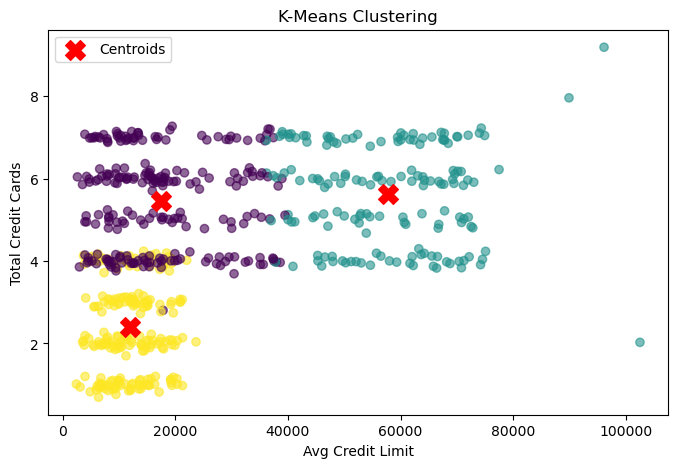

In [15]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["Avg_Credit_Limit"],
    df_clean["Total_Credit_Cards"],
    c=df_clean["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.6,
)
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=200,
    c="red",
    marker="X",
    label="Centroids",
)
plt.xlabel("Avg Credit Limit")
plt.ylabel("Total Credit Cards")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

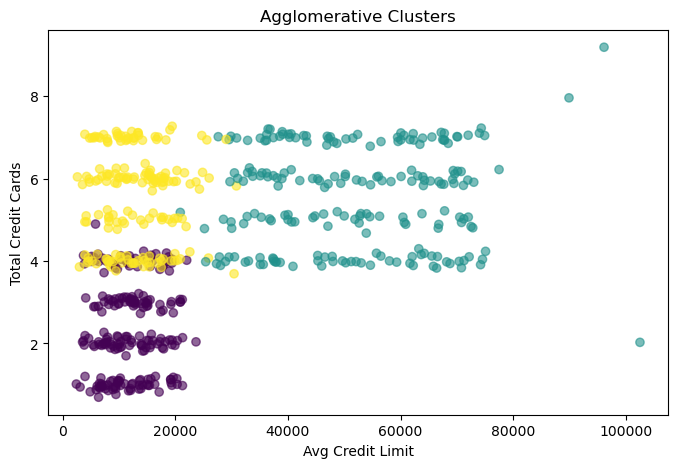

In [16]:
# Agglomerative scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["Avg_Credit_Limit"],
    df_clean["Total_Credit_Cards"],
    c=df_clean["Agg_Cluster"],
    cmap="viridis",
    alpha=0.6,
)
plt.title("Agglomerative Clusters")
plt.xlabel("Avg Credit Limit")
plt.ylabel("Total Credit Cards")
plt.show()

#### Analysis of Models:

Both the Agglormative and K means clustering show some distinction between people with lower vs higher credit limits. The models groups people with less than $20,000 credit limit and less than 4 credit cards nearly identical. Where the models seem to have differences with clustering is the distinction between low and high credit limit for the  group that have more than 4 credit cards. The difference between the distinction is not by much, but I think considering how much more data is in those groups it makes sense for a difference in bounds. 

### Step 8:  Calculate silhouette scores and Davies-Bouldin scores for different k values.

In [17]:
sil_scores = []
db_scores = []
sil_scores_agg = []
db_scores_agg = []

for k in k_values:
    km_labels = KMeans(n_clusters=k,
                       random_state=42).fit_predict(X)
    agg_labels = AgglomerativeClustering(n_clusters=k,
                                         linkage="ward").fit_predict(X)

    sil_scores.append(silhouette_score(X, km_labels))
    db_scores.append(davies_bouldin_score(X, km_labels))
    sil_scores_agg.append(silhouette_score(X, agg_labels))
    db_scores_agg.append(
        davies_bouldin_score(X, agg_labels))

# Print results as a table
results_df = pd.DataFrame(
    {
        "k": list(k_values),
        "KMeans Silhouette": sil_scores,
        "Agg Silhouette": sil_scores_agg,
        "KMeans Davies-Bouldin": db_scores,
        "Agg Davies-Bouldin": db_scores_agg,
    }
)

results_df

,k,KMeans Silhouette,Agg Silhouette,KMeans Davies-Bouldin,Agg Davies-Bouldin
0,2,0.476565,0.476135,0.821671,0.823221
1,3,0.378117,0.357398,1.135006,1.170673
2,4,0.315795,0.249787,1.334854,1.562398
3,5,0.320924,0.180994,1.148244,1.872177
4,6,0.234218,0.182118,1.379665,1.772158
5,7,0.218139,0.187925,1.471567,1.574568
6,8,0.195095,0.179371,1.577390,1.484479
7,9,0.191289,0.173344,1.563522,1.472243
8,10,0.182538,0.167132,1.546472,1.429515


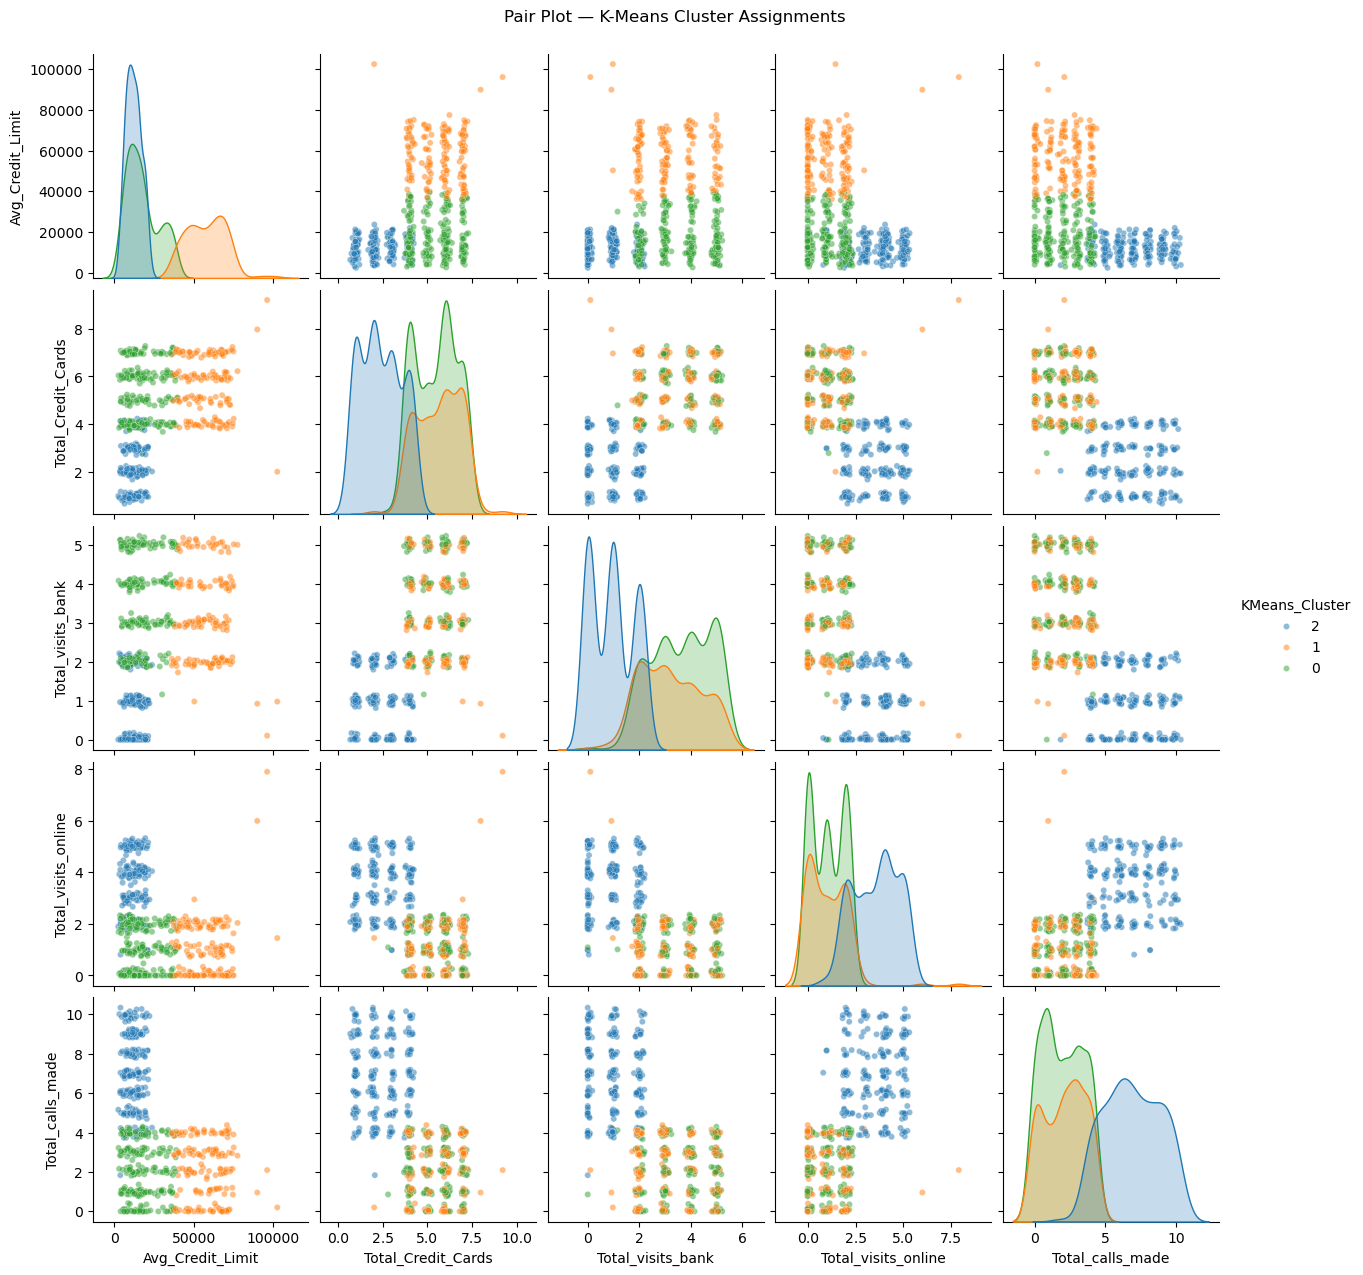

In [18]:
# Pair plot across all features colored by K-Means cluster
plot_df = df_clean.drop(columns=["Agg_Cluster"]).copy()
plot_df["KMeans_Cluster"] = plot_df["KMeans_Cluster"].astype(str)

sns.pairplot(
    plot_df, hue="KMeans_Cluster",
    palette="tab10", plot_kws={"alpha": 0.5, "s": 20}
)
plt.suptitle("Pair Plot — K-Means Cluster Assignments", y=1.02)
plt.show()

#### Step 9: Silhoutte Plot

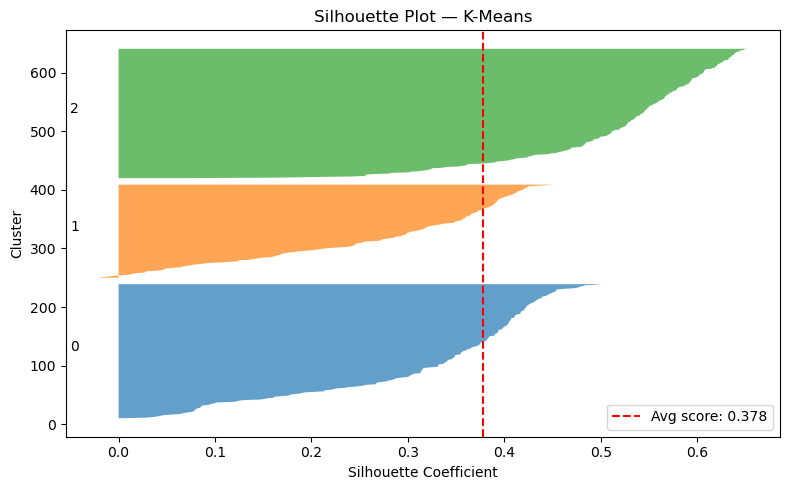

In [ ]:
# Per-sample silhouette coefficients for K-Means
labels = df_clean["KMeans_Cluster"].values
sil_vals = silhouette_samples(X, labels)
avg_score = sil_vals.mean()

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10

for i in range(optimal_k):
    cluster_vals = np.sort(sil_vals[labels == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_vals, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(
    x=avg_score, color="red", linestyle="--",
    label=f"Avg score: {avg_score:.3f}"
)
ax.set_title("Silhouette Plot — K-Means")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.show()

### Overall Analysis

*How well did K-Means and Hierarchical Clustering segment the data?*


Both models produced similar customer segments, with the clearest separation along Avg_Credit_Limit. Customers with credit limits below $20,000 were grouped about the same by both methods, showing that low credit customers are a separate group. The main difference was in how each method divided customers with higher credit card counts — K-Means drew cleaner boundaries near the $40,000 line while Agglomerative Clustering followed the data density more closely. Overall both methods confirmed the same high-level structure: a low credit limit group, a mid-range group, and a high credit limit group.

*What challenges did you encounter in feature scaling and outlier detection?*

The challenge with outlier detection was that it completely removed a set of high credit limit records, which I could see changing the bounds of the clustering if it was not removed.

*How do silhouette and Davies-Bouldin scores help in cluster evaluation?*


Silhouette scores measure how similar each point is to its own cluster compared to neighboring clusters — a score closer to 1 means well-separated clusters, closer to 0 means overlapping.